In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from itertools import product
import hexMinisom
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as mpath
from matplotlib import colormaps
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf
import pickle
import itertools
import colorsys
import random
import datetime as dt
import string
from matplotlib.patches import ConnectionPatch

In [2]:
def load_som(fileName):
    with open(fileName, 'rb') as infile:
        som = pickle.load(infile)
    return som

# Get the counts of each WR_label for each node in SOM
def get_WR_counts(l, return_percents=False, indices=None):

    # Take only the data from days with the given indices in indices
    if indices is None:
        labels, counts = np.unique([WR_labels[i] for i in l], return_counts=True)
    else:
        labels, counts = np.unique([WR_labels[i] for i in l if i in indices], return_counts=True)

    # If the node has no days of a given regime add the regime to the labels and 0 as its count
    if len(labels) != len(WR_labels_dict.keys()):
        missing_values = np.setdiff1d(list(WR_labels_dict.keys()), labels)

        labels = WR_labels_dict.keys()

        for v in missing_values:
           counts = np.insert(counts, v, 0)

    # Calculate the percents
    if return_percents:
        counts = 100 * counts / sum(counts)

    regime_counts = dict(zip(labels, counts))

    return regime_counts

def get_wr_distances(df, exclude_wr=5):
    distances = df["distances"].to_numpy()
    wr_ids = df["WR"].to_numpy()

    out = {}
    for wr in np.unique(wr_ids):
        if wr == exclude_wr:
            continue
        out[int(wr)] = distances[wr_ids == wr]
    return out

def pick_wr_id_by_label(wr_dists, wr_labels_dict, target_label):
    for wr_id in wr_dists.keys():
        if wr_labels_dict.get(wr_id) == target_label:
            return wr_id
    raise ValueError(f"No WR id found with label '{target_label}'.")

def y_at_hist_bin(v, x, num_bins, bin_min, bin_max):
    counts, edges = np.histogram(v, bins=num_bins, range=(bin_min, bin_max))
    centers = 0.5 * (edges[:-1] + edges[1:])
    idx = int(np.argmin(np.abs(centers - x)))
    bump = 0.02 * float(counts.max() if counts.size else 1.0)
    return float(counts[idx]) + bump

def stylize_map_axis(ax, rect_path, extent, fontsize):
    ax.coastlines(resolution="110m", color="k", linewidth=0.75, zorder=10)
    ax.margins(x=0, y=0)
    ax.add_feature(cfeature.BORDERS, edgecolor="gray", linewidth=0.5, zorder=5)
    ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.25, zorder=5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_boundary(rect_path, transform=ccrs.PlateCarree())

In [3]:
dataset = xr.open_dataarray('/glade/work/molina/DATA/Z500Anoms_ERA5.nc')

latSlice = slice(20, 80) #20N, 80N
lonSlice = slice(180, 330) #180W, 30W
dataarray = dataset.sel(lat=latSlice, lon=lonSlice)
dataarray = dataarray.stack(latlon=['lat', 'lon']).values

# Set up our lats and lons
lats = dataset.sel(lat=latSlice, lon=lonSlice).lat
lons = dataset.sel(lat=latSlice, lon=lonSlice).lon - 360
lons, lats = np.meshgrid(lons, lats)

print(dataarray.shape)

(30660, 9211)


In [4]:
som = load_som('SOM40.p')

n = som._num
xy = hexMinisom.xy_using_n(n)

mask = som._mask
node_indices_xy = np.ma.where(mask == False)
node_indices = list(zip(node_indices_xy[0], node_indices_xy[1]))
all_nodes = product(range(xy), range(xy))

winmap = som.win_map(dataarray, return_indices=True)

In [5]:
# Import the regime labels
WR_labels_df = pd.read_csv('df_labels_nocorrfilt_ERA5.csv')
WR_labels_df.rename(columns={'Unnamed: 0': 'date'}, inplace=True)
WR_labels_df['date'] = pd.to_datetime(WR_labels_df['date'], format='%Y-%m-%d')
WR_labels_dict = {
    0: 'Polar High', 1: 'Pacific Trough', 2: 'Pacific Ridge', 
    3: 'Alaskan Ridge', 4: 'Atlantic Ridge', 5: 'No WR'
}
WR_labels = np.array(WR_labels_df['WR'])

WRs_by_node = {k: get_WR_counts(v) for k, v in winmap.items()}
WRs_percents = {k: get_WR_counts(v, return_percents=True) for k, v in winmap.items()}

print(WR_labels_df)

            date  WR  distances      corr
0     1940-01-01   0   2.463938  0.518457
1     1940-01-02   0   2.662645  0.565398
2     1940-01-03   0   2.916932  0.552532
3     1940-01-04   0   3.122750  0.495652
4     1940-01-05   0   3.302769  0.394692
...          ...  ..        ...       ...
30655 2023-12-27   1   2.823370  0.857459
30656 2023-12-28   1   2.687266  0.837698
30657 2023-12-29   1   2.394127  0.781903
30658 2023-12-30   1   2.253624  0.655454
30659 2023-12-31   0   2.468174  0.359541

[30660 rows x 4 columns]


In [6]:
WR_NUM = 1
WR_NAM = "Pacific Trough"

In [7]:
# get the closest and furthest distance days
closest  = min(WR_labels_df[WR_labels_df['WR'] == WR_NUM]['distances'])
furthest = max(WR_labels_df[WR_labels_df['WR'] == WR_NUM]['distances'])
cidx = WR_labels_df[WR_labels_df['distances'] == closest].index[0]
fidx = WR_labels_df[WR_labels_df['distances'] == furthest].index[0]
cdata = dataarray[cidx].reshape((lons.shape[0], lats.shape[1]))
fdata = dataarray[fidx].reshape((lons.shape[0], lats.shape[1]))

# get the regime mean
wr_idxs = np.array(WR_labels == WR_NUM).nonzero()[0]
regime_mean = np.mean(dataarray[wr_idxs], axis=0).reshape((lons.shape[0], lats.shape[1]))

In [8]:
minCorr = min(WR_labels_df[WR_labels_df['WR'] == WR_NUM]['corr'])
maxCorr = max(WR_labels_df[WR_labels_df['WR'] == WR_NUM]['corr'])

minCorrDay = WR_labels_df[WR_labels_df['corr'] == minCorr]['date']
maxCorrDay = WR_labels_df[WR_labels_df['corr'] == maxCorr]['date']

minCorrIdx = WR_labels_df[WR_labels_df['corr'] == minCorr].index[0]
maxCorrIdx = WR_labels_df[WR_labels_df['corr'] == maxCorr].index[0]

minCoorData = dataarray[minCorrIdx].reshape((lons.shape[0], lats.shape[1]))
maxCoorData = dataarray[maxCorrIdx].reshape((lons.shape[0], lats.shape[1]))

print(minCorr)
print(maxCorr)
print(minCorrDay)
print(maxCorrDay)

-0.2062403080500476
0.9285790047754868
1271   1943-06-26
Name: date, dtype: datetime64[ns]
27711   2015-12-03
Name: date, dtype: datetime64[ns]


In [9]:
minDist = min(WR_labels_df[WR_labels_df['WR'] == WR_NUM]['distances'])
maxDist = max(WR_labels_df[WR_labels_df['WR'] == WR_NUM]['distances'])

minDistDay = WR_labels_df[WR_labels_df['distances'] == minDist]['date'].values[0]
maxDistDay = WR_labels_df[WR_labels_df['distances'] == maxDist]['date'].values[0]

minDistIdx = WR_labels_df[WR_labels_df['distances'] == minDist].index[0]
maxDistIdx = WR_labels_df[WR_labels_df['distances'] == maxDist].index[0]

minDistData = dataarray[minDistIdx].reshape((lons.shape[0], lats.shape[1]))
maxDistData = dataarray[maxDistIdx].reshape((lons.shape[0], lats.shape[1]))

corrForMinDist = WR_labels_df[WR_labels_df['distances'] == minDist]['corr'].values[0]
corrForMaxDist = WR_labels_df[WR_labels_df['distances'] == maxDist]['corr'].values[0]

print(minDist)
print(maxDist)
print(minDistDay)
print(maxDistDay)

1.2193592373772562
6.096313615515868
1998-12-15T00:00:00.000000000
1970-10-31T00:00:00.000000000


In [26]:
x_max_dist

6.096313615515868

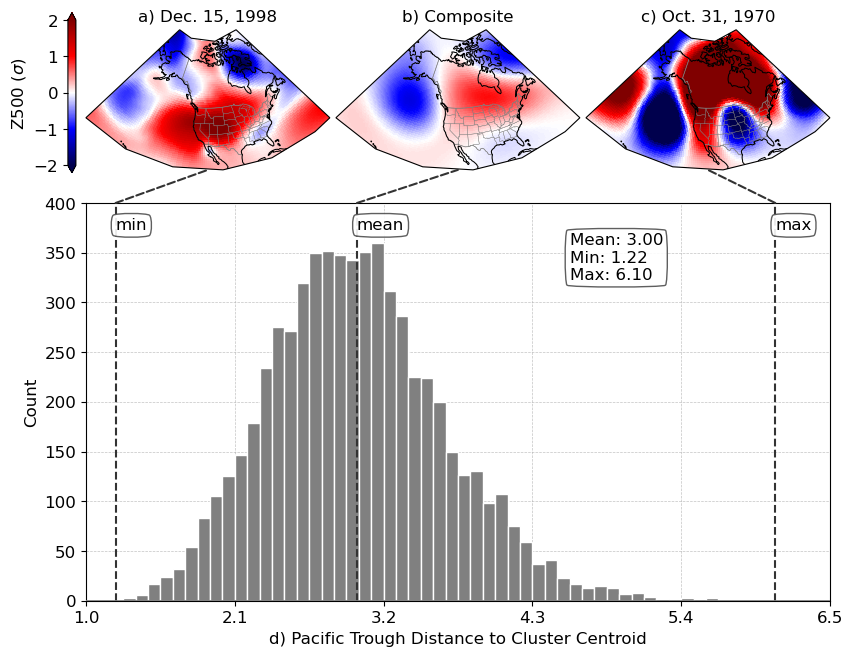

In [140]:
# Histogram regime selection:
TARGET_LABEL = WR_NAM
EXCLUDE_WR = 5
NUM_BINS = 60

abcd = list(string.ascii_lowercase)
fontsize_most_things = 12
mini=-2
maxi=2

# -------------------------------------------------------------------
# Prepare distances for the histogram
# -------------------------------------------------------------------
wr_dists = get_wr_distances(WR_labels_df, exclude_wr=EXCLUDE_WR)
target_wr_id = pick_wr_id_by_label(wr_dists, WR_labels_dict, TARGET_LABEL)
v = wr_dists[target_wr_id]

bin_min = float(np.min(v))
bin_max = float(np.max(v))

x_min_dist = float(np.min(v))
x_max_dist = float(np.max(v))
x_mean = float(np.mean(v))

proj = ccrs.AlbersEqualArea(
    central_longitude=-115,
    central_latitude=50,
    standard_parallels=(30, 70),
)

# -------------------------------------------------------------------

fig = plt.figure(figsize=(8, 8))

# Tight map alignment like your example
gs = fig.add_gridspec(
    nrows=2, 
    ncols=3,
    height_ratios=[0.6, 0.9],   # maps row, histogram row
    left=0.06, right=0.99, top=0.95, bottom=0.08,
    wspace=0.025, 
    hspace=0.1    # negative wspace matches your preferred lineup
)

axes = np.array([
    fig.add_subplot(gs[0, 0], projection=proj),
    fig.add_subplot(gs[0, 1], projection=proj),
    fig.add_subplot(gs[0, 2], projection=proj),
])

hist_ax = fig.add_subplot(gs[1, :])  # histogram spans all 3 columns

# -------------------------------------------------------------------
# Map boundary setup (rectangle)
# -------------------------------------------------------------------
extent = [-180, -50, 20, 80]
verts = [
    (extent[0], extent[2]),
    (extent[1], extent[2]),
    (extent[1], extent[3]),
    (extent[0], extent[3]),
    (extent[0], extent[2]),
]
rect_path = mpath.Path(verts)

# -------------------------------------------------------------------
# Panel a) Composite
# -------------------------------------------------------------------
pm = axes[1].pcolormesh(
    lons, lats, regime_mean,
    transform=ccrs.PlateCarree(),
    vmin=mini, vmax=maxi, cmap="seismic"
)
axes[1].set_title(f"{abcd[1]}) Composite", fontsize=fontsize_most_things, loc="center")
stylize_map_axis(axes[1], rect_path, extent, fontsize_most_things)

# -------------------------------------------------------------------
# Panel b) Example 1
# -------------------------------------------------------------------
pm = axes[0].pcolormesh(
    lons, lats, cdata,
    transform=ccrs.PlateCarree(),
    vmin=mini, vmax=maxi, cmap="seismic"
)
axes[0].set_title(f"{abcd[0]}) Dec. 15, 1998", fontsize=fontsize_most_things, loc="center")
stylize_map_axis(axes[0], rect_path, extent, fontsize_most_things)

# -------------------------------------------------------------------
# Panel c) Example 2
# -------------------------------------------------------------------
pm = axes[2].pcolormesh(
    lons, lats, fdata,
    transform=ccrs.PlateCarree(),
    vmin=mini, vmax=maxi, cmap="seismic"
)
axes[2].set_title(f"{abcd[2]}) Oct. 31, 1970", fontsize=fontsize_most_things, loc="center")
stylize_map_axis(axes[2], rect_path, extent, fontsize_most_things)

# -------------------------------------------------------------------
# Colorbar (positioned similarly to your example)
# Place it in figure coordinates in the gap between row 0 and row 1
# -------------------------------------------------------------------
# Compute a y-position between the two grid rows
maps_bottom = min(ax.get_position().y0 for ax in axes)
hist_top = hist_ax.get_position().y1
gap_mid = hist_top + 0.5 * (maps_bottom - hist_top)

cbar_height = 0.20
cbar_width = 0.01
cbar_left = 0.0375
cbar_bottom = 0.615

cbar_ax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
ticks_1 = [-2, -1, 0, 1, 2]
cbar = fig.colorbar(pm, cax=cbar_ax, ticks=ticks_1, orientation="vertical", extend="both")
cbar_ax.yaxis.set_ticks_position("left")
cbar_ax.yaxis.set_label_position("left")
cbar.ax.tick_params(labelsize=fontsize_most_things)
cbar.set_label(r"Z500 ($\sigma$)", fontsize=fontsize_most_things)

# -------------------------------------------------------------------
# Histogram (below the three panels)
# -------------------------------------------------------------------
hist_ax.hist(
    v,
    bins=NUM_BINS,
    range=(1.0, 6.5),
    alpha=1,
    color="grey",
    edgecolor='w',
    label=TARGET_LABEL,
    zorder=10
)

# Min/Max markers (these are the connector origins)
hist_ax.axvline(x_min_dist, color="0.2", linestyle="--", linewidth=1.5, zorder=11)
hist_ax.axvline(x_max_dist, color="0.2", linestyle="--", linewidth=1.5, zorder=11)

# Optional mean marker
hist_ax.axvline(x_mean, color="0.2", linestyle="--", linewidth=1.5, zorder=11)

#hist_ax.set_title(f"d) {TARGET_LABEL} Distance to Cluster Center", fontsize=fontsize_most_things)
hist_ax.set_ylabel("Count", fontsize=fontsize_most_things)
hist_ax.set_xlabel("d) Pacific Trough Distance to Cluster Centroid", fontsize=fontsize_most_things)

# Custom ticks (adjust as you like)
xticks = np.linspace(1.0, 6.5, 6)
hist_ax.set_xticks(xticks)
hist_ax.set_xlim(1.0, 6.5)
hist_ax.set_ylim(0, 400)
hist_ax.tick_params(axis="both", labelsize=fontsize_most_things)

hist_ax.text(
    0.65, 0.925,
    f"Mean: {x_mean:.2f}\nMin: {x_min_dist:.2f}\nMax: {x_max_dist:.2f}",
    transform=hist_ax.transAxes, va="top", ha="left", fontsize=fontsize_most_things, zorder=30,
    bbox=dict(boxstyle="round4,pad=0.3", fc="white", ec="0.3", lw=1, alpha=0.9)
)

hist_ax.axhline(0, color="grey", linewidth=2.0, zorder=12)

# -------------------------------------------------------------------
# Connectors: histogram -> panels b and c ONLY
#   - connect from min bin to panel b
#   - connect from max bin to panel c
# Lines touch the map axes boundary; no specific geo location
# -------------------------------------------------------------------
y_min = y_at_hist_bin(v, x_min_dist, NUM_BINS, bin_min, bin_max)
y_max = y_at_hist_bin(v, x_max_dist, NUM_BINS, bin_min, bin_max)

# Touch points on the bottom edge of panels b and c (axes fraction coords)
# y=0.0 means bottom boundary; x=0.5 means centered
panel_a_touch = (0.5, 0.0)
panel_b_touch = (0.5, 0.0)
panel_c_touch = (0.5, 0.0)

con_a = ConnectionPatch(
    xyA=(x_min_dist, 400), coordsA=hist_ax.transData,
    xyB=panel_a_touch,     coordsB=axes[0].transAxes,
    color="0.2", linestyle="--", linewidth=1.5
)
con_a.set_clip_on(False)
con_a.set_zorder(35)
hist_ax.add_artist(con_a)

con_b = ConnectionPatch(
    xyA=(x_mean, 400), coordsA=hist_ax.transData,
    xyB=panel_b_touch,     coordsB=axes[1].transAxes,
    color="0.2", linestyle="--", linewidth=1.5,
)
con_b.set_clip_on(False)
con_b.set_zorder(35)
hist_ax.add_artist(con_b)

con_c = ConnectionPatch(
    xyA=(x_max_dist, 400), coordsA=hist_ax.transData,
    xyB=panel_c_touch,       coordsB=axes[2].transAxes,
    color="0.2", linestyle="--", linewidth=1.5
)
con_c.set_clip_on(False)
con_c.set_zorder(35)
hist_ax.add_artist(con_c)

# Optional small labels at the connector origins
hist_ax.text(x_min_dist, 370, "min", va="bottom", ha="left", fontsize=fontsize_most_things, zorder=100,
             bbox=dict(boxstyle="round4,pad=0.3", fc="white", ec="0.3", lw=1, alpha=0.9))
hist_ax.text(x_max_dist, 370, "max", va="bottom", ha="left", fontsize=fontsize_most_things, zorder=100,
             bbox=dict(boxstyle="round4,pad=0.3", fc="white", ec="0.3", lw=1, alpha=0.9))
hist_ax.text(x_mean, 370, "mean", va="bottom", ha="left", fontsize=fontsize_most_things, zorder=100,
             bbox=dict(boxstyle="round4,pad=0.3", fc="white", ec="0.3", lw=1, alpha=0.9))

hist_ax.grid(zorder=0, alpha=0.75, ls='--', lw=0.5)

for ax in axes:
    ax.set_anchor('S')   # 'S' = south (bottom). Try 'SW' if you prefer.
# -------------------------------------------------------------------
# Save / show
# -------------------------------------------------------------------
plt.savefig("PT_Diversity_updated.pdf", transparent=True, bbox_inches="tight")
plt.show()